In [14]:
%matplotlib inline

In [15]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_fault_zone_mode_2" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [16]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [17]:
# Layered model setup: three layers ordered as snow, weak layer (wl), air.

x_min, x_max = 0.0, 300.0

# Geometry (high y = top of domain ):
slab_bottom = 0.0
slab_thickness = 1.0
wl_thickness = 0.05
domain_top = 3.0

slab_top = slab_bottom + slab_thickness # snow-wl interface
wl_bottom = slab_top
wl_top = wl_bottom + wl_thickness # wl-air interface
air_top = domain_top

# Boundaries from top to bottom -> 3 layers.
layers_x = [
    np.array([x_min, x_max]),  # top boundary
    np.array([x_min, x_max]),  # air-wl interface
    np.array([x_min, x_max]),  # wl-snow interface
    np.array([x_min, x_max]),  # bottom boundary
]
layers_y = [
    np.array([air_top, air_top]),
    np.array([wl_top, wl_top]),
    np.array([wl_bottom, wl_bottom]),
    np.array([slab_bottom, slab_bottom]),
]

# Material parameters by region index [snow, weak layer, air].
vp = np.array([300.0, 120.0, 332.0])
vs = np.array([150.0, 60.0, 0.0])
rho = np.array([180.0, 150.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

max_frequency = 50.0
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 60.0, 60.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  Snow layer: y = [{slab_bottom:.2f}, {slab_top:.2f}] m, vs=150 m/s")
print(f"  Weak layer: y = [{wl_bottom:.2f}, {wl_top:.2f}] m, vs=60 m/s")
print(f"  Air layer:  y = [{wl_top:.2f}, {air_top:.2f}] m, vs=0 m/s")

Three-layer mesh built.
  Snow layer: y = [0.00, 1.00] m, vs=150 m/s
  Weak layer: y = [1.00, 1.05] m, vs=60 m/s
  Air layer:  y = [1.05, 3.00] m, vs=0 m/s


In [18]:
# Writing standard rupture format file: based on https://www.mondaic.com/case-studies/accurate-fault-planes-in-earthquake-ground-motion-modeling

def write_snow_crack_srf(
    filepath,
    crack_x_start=30.0,
    crack_x_end=270.0,
    crack_y=wl_bottom + wl_thickness / 2.0, # crack is in the mdidle of weak layer
    n_subfaults=120,
    rupture_speed=125.0,  # m/s - sub-Rayleigh (vs_weak=60, vs_slab=150)
    rise_time=0.02, # second s duration of slip at each subfault
    total_slip=0.01, # m : max slip (10 mm), realistic for PST
    mode_mix=1,# fraction of shear (Mode II) vs opening (Mode I): if this is 1.0, it's pure shear; if 0.0, it's pure openingh 
    f0=10.0, # Ricker center frequency
):
    """
    Write an SRF-like ASCII file for a 2D horizontal snow crack.
    
    In 2D Cartesian Salvus, we approximate the SRF concept by generating
    the subfault parameters analytically and writing them in a format that
    maps to MomentTensorPoint2D sources with per-subfault STFs.
    
    The function returns the list of (x, y, delay, mxx, myy, mxy, rise_time)
    tuples so they can be passed directly to Salvus.
    """
    crack_length = crack_x_end - crack_x_start
    dx = crack_length / (n_subfaults - 1)
    x_positions = np.linspace(crack_x_start, crack_x_end, n_subfaults)

    # Onset time: crack initiates at x_start, propagates at rupture_speed
    onset_times = (x_positions - crack_x_start) / rupture_speed

    # Slip distribution: elliptical (Kostrov- like), tapered at tips
    xi = (x_positions - crack_x_start) / crack_length  # 0 to 1
    slip_distribution = total_slip * np.sqrt(np.maximum(0, xi * (1 - xi)) * 4)

    # Moment tensor components (2D plane strain):
    # Mode II (shear): mxy - slip along x, interface normal is y
    # Mode I (opening): myy - normal opening
    # Scale by shear modulus of weak layer: mu = rho * vs^2
    mu_weak = 150.0 * 60.0**2    # ~540 kPa
    lam_weak = rho[1] * (vp[1]**2 - 2 * vs[1]**2)  # for Mode I

    subfaults = []
    for i, (x_src, t_onset, slip) in enumerate(zip(x_positions, onset_times, slip_distribution)):
        # Seismic moment per unit length (2D) = mu * slip * patch_width
        M0 = mu_weak * slip * dx

        # Mixed-mode moment tensor in 2D:
        # Mode II shear: Mxy component
        # Mode I opening: Myy component (tensile)
        mxy = mode_mix * M0
        myy = (1.0 - mode_mix) * M0
        mxx = 0.0  # no out-of-plane contribution in 2D

        subfaults.append({
            "x": float(x_src),
            "y": float(crack_y),
            "onset_time": float(t_onset),
            "rise_time": rise_time,
            "mxx": mxx,
            "myy": myy,
            "mxy": mxy,
            "slip": slip,
        })

    # Save to file for documentation
    with open(filepath, "w") as f:
        f.write("# Snow crack SRF-equivalent descriptor\n")
        f.write(f"# crack_y={crack_y:.4f} m, rupture_speed={rupture_speed} m/s\n")
        f.write(f"# n_subfaults={n_subfaults}, rise_time={rise_time} s\n")
        f.write("# x_m  y_m  onset_s  rise_s  mxx  myy  mxy  slip_m\n")
        for sf in subfaults:
            f.write(
                f"{sf['x']:.4f}  {sf['y']:.4f}  {sf['onset_time']:.6f}  "
                f"{sf['rise_time']:.4f}  {sf['mxx']:.4f}  {sf['myy']:.4f}  "
                f"{sf['mxy']:.4f}  {sf['slip']:.6f}\n"
            )

    print(f"Wrote {len(subfaults)} subfaults to {filepath}")
    print(f"  Crack length: {crack_length:.1f} m")
    print(f"  Rupture duration: {onset_times[-1]:.3f} s")
    print(f"  Peak slip: {slip_distribution.max():.4f} m")
    print(f"  Max M0 (per subfault): {max(abs(sf['mxy'])+abs(sf['myy']) for sf in subfaults):.2e} N")
    return subfaults


srf_path = pathlib.Path(PROJECT_DIR) / "snow_crack.srf_equiv"
srf_path.parent.mkdir(exist_ok=True)

subfaults = write_snow_crack_srf(
    srf_path,
    crack_x_start=30.0,
    crack_x_end=270.0,
    crack_y=wl_bottom + wl_thickness / 2.0,
    n_subfaults=120,
    rupture_speed=125.0, # sub-Rayleigh, change for supershera
    rise_time=0.02,
    total_slip=0.01,
    mode_mix=0.7,
    f0=10.0,
)

Wrote 120 subfaults to simulation_fault_zone_mode_2/snow_crack.srf_equiv
  Crack length: 240.0 m
  Rupture duration: 1.920 s
  Peak slip: 0.0100 m
  Max M0 (per subfault): 1.09e+04 N


In [19]:
# Using srf to build source array 

def build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3):
    """
    Convert the SRF subfault list into Salvus MomentTensorPoint2D sources,
    each with a Ricker STF delayed to match the subfault onset time.
    The rise_time modulates the effective STF width.
    """
    srcs = []
    for sf in subfaults:
        # Effective time shift: pre_delay + crack onset + half rise-time
        time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0
        
        src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
            x=sf["x"],
            y=sf["y"],
            mxx=sf["mxx"],
            myy=sf["myy"],
            mxy=sf["mxy"],
            source_time_function=sn.simple_config.stf.Ricker(
                center_frequency=f0,
                time_shift_in_seconds=time_shift,
            ),
        )
        srcs.append(src)

    print(f"Built {len(srcs)} Salvus sources from SRF descriptor.")
    print(f"  STF time shifts span {pre_delay:.2f}s to {srcs[-1].source_time_function.time_shift_in_seconds:.3f}s")
    return srcs


crack_srcs = build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3)

crack_event_name = "event_snow_crack_srf"
if crack_event_name in p.events.list():
    p.events.delete(event_name=crack_event_name)

p.add_to_project(sn.Event(event_name=crack_event_name, sources=crack_srcs))
print(f"Added event '{crack_event_name}' with {len(crack_srcs)} sources.")

Built 120 Salvus sources from SRF descriptor.
  STF time shifts span 0.30s to 2.230s
[2026-04-22 14:29:25,143] INFO: A source for event `event_snow_crack_srf` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-22 14:29:25,143] INFO: A source for event `event_snow_crack_srf` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-22 14:29:25,143] INFO: A source for event `event_snow_crack_srf` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-22 14:29:25,144] INFO: A source for event `event_snow_crack_srf` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The 

In [20]:

crack_sim_name = "sim_snow_crack_3layer"

p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name=crack_sim_name,
        unstructured_mesh=mesh_3layer,
        event_configuration=sn.EventConfiguration(
            wavelet=sn.simple_config.stf.Delta(),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=3.0, # longer becasue crack takes abt 1.9s to traverse 240m at 125 m/s
            ),
        ),
    ),
    overwrite=True,
)

input_file = p.simulations.get_simulation_template(crack_sim_name, crack_event_name)
input_file.add_sources(crack_srcs)

# Validate source count
assert len(input_file.physics.wave_equation.point_source) == len(crack_srcs), \
    f"Source count mismatch: {len(input_file.physics.wave_equation.point_source)} vs {len(crack_srcs)}"

# Request volume and  surface output
del input_file.output.point_data

input_file.output.volume_data = {
    "filename": "volume_data_crack.h5",
    "format": "hdf5",
    "fields": ["velocity", "displacement", "strain"],
    "sampling_interval_in_time_steps": 50,
}

input_file.validate()

# Launch simulations 
crack_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_3layer")
crack_job = sn.api.run(
    input_file=input_file,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=crack_output_folder,
    get_all=True,
    overwrite=True,
)
print(f"Run finished. Output: {crack_output_folder}")

SalvusJob `job_2604221429544964_2c5e811161` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/54380 [00:00<?, ?it/s]

* Downloaded 1.4 GB of results to `simulation_fault_zone_mode_2/job_snow_crack_3layer`.
* Total run time: 54.65 seconds.
* Pure simulation time: 52.60 seconds.
Run finished. Output: simulation_fault_zone_mode_2/job_snow_crack_3layer


In [21]:
# Extract displacement wavefield output from the single combined run.
vol_file = pathlib.Path(crack_output_folder) / "volume_data_crack.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/12341 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/10941 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

[2026-04-22 14:30:40,004] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 10234 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded displacement from simulation_fault_zone_mode_2/job_snow_crack_3layer/volume_data_crack.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 1089, c: 2, x: 301, y: 101)> Size: 265MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[            nan,  

In [22]:
# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Computed spatial derivative d/dx for dis_2d_layered
<xarray.DataArray (t: 1089, c: 2, x: 301, y: 101)> Size: 265MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [     

In [23]:
# Extract velocity wavefield output from the single combined run.
vol_file = pathlib.Path(crack_output_folder) / "volume_data_crack.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/12341 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/10941 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

[2026-04-22 14:31:01,728] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 10234 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded velocity from simulation_fault_zone_mode_2/job_snow_crack_3layer/volume_data_crack.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 1089, c: 2, x: 301, y: 101)> Size: 265MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[            nan,      

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.001213681500551
vx shape: (1089, 301)
vy shape: (1089, 301)


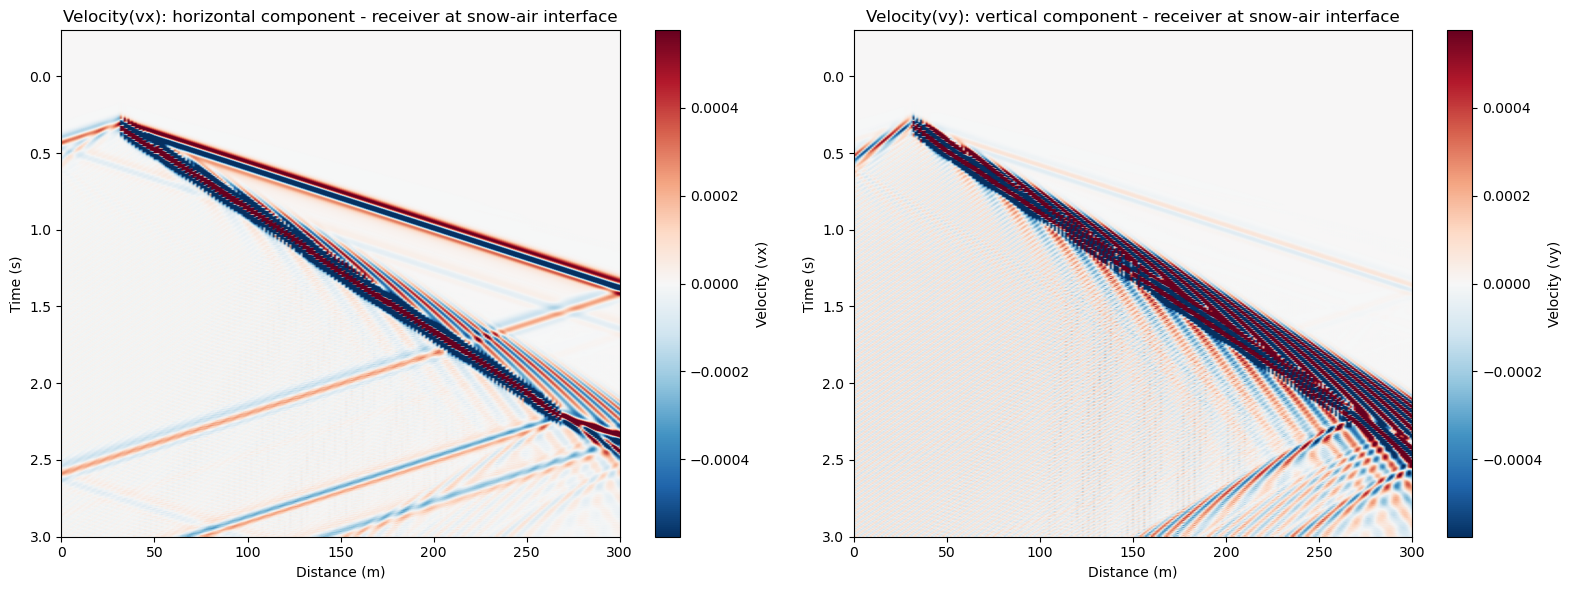

In [24]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 1.5 # This would be at snow-air boundary 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.001213681500551
vx shape: (1089, 301)
vy shape: (1089, 301)


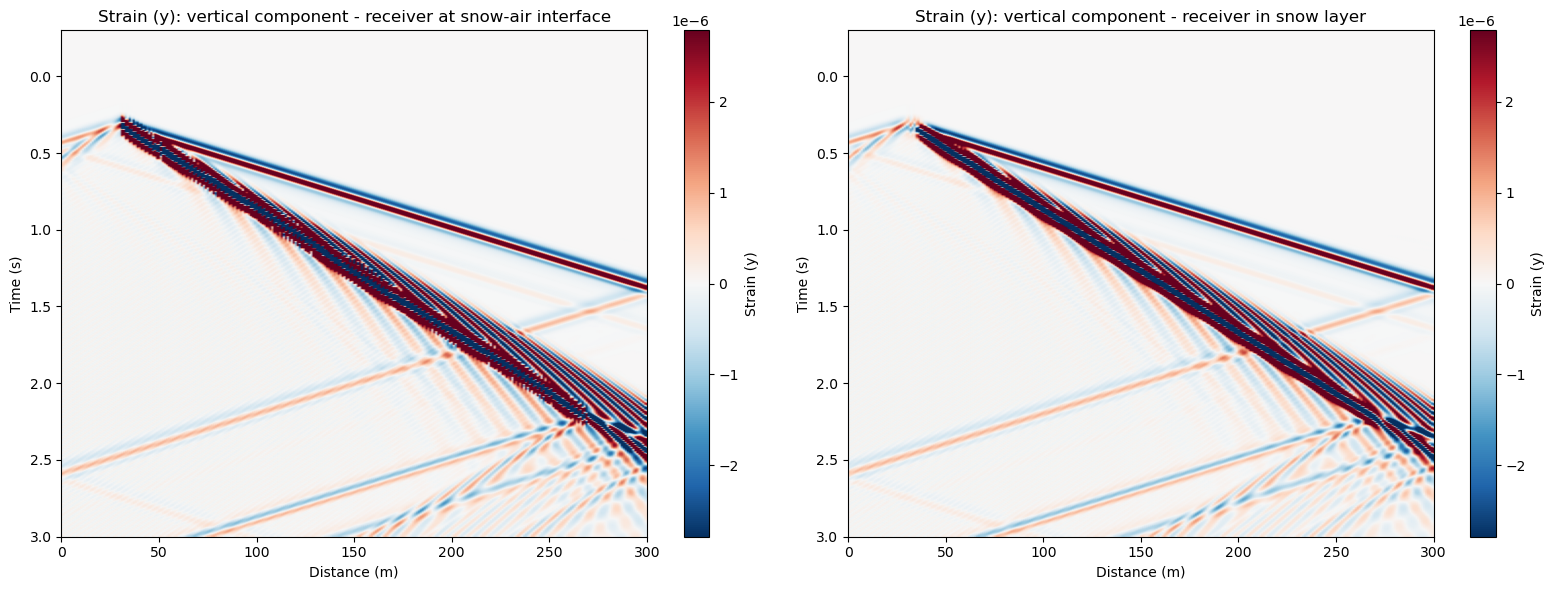

In [25]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 1.5
y_surface_2 = 2.5

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Strain (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Strain (y): vertical component - receiver in snow layer")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


In [ ]:
# Build a combined field across all events, matching the waterfall plot logic.
vy_event = vel_2d_layered.isel({c_name: 1})
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)

# Extract raw coordinates and data the same way as static source
# vy_event dims should be (t, y, x) after transpose
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals = vy_event[x_name].values
y_vals = vy_event[y_name].values
t_vals = vy_event[t_name].values
frames_3d = np.asarray(vy_event.values, dtype=np.float64)
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Time subsampling starting from t=0
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 5  # Subsample: take every 5th frame to reduce file size
t_idx = np.arange(t_start_idx, frames_3d.shape[0], N)

# Robust SymLogNorm scaling — same as static source
warmup = max(1, len(frames_3d) // 4)
abs_vals = np.abs(frames_3d[warmup:]).ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]
abs_vals = abs_vals[abs_vals > 1e-14]

if abs_vals.size == 0:
    vmax = 1e-8
    linthresh = 1e-10
else:
    vmax = float(np.percentile(abs_vals, 99.5))
    vmax = max(vmax, 1e-8)
    linthresh = max(float(np.percentile(abs_vals, 70)), vmax * 1e-3, 1e-10)

print("representative_event: combined over all events")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim: {len(t_idx)}")
print(f"vmax={vmax:.3e}, linthresh={linthresh:.3e}")


def run_animation():
    try:
        from matplotlib import colors
        from matplotlib import ticker

        norm = colors.SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax,
            base=10,
        )

        # Avoid mathtext parsing issues in tick labels (especially with SymLog colorbar).
        plt.rcParams["axes.formatter.use_mathtext"] = False

        fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

        im = ax.imshow(
            frames_3d[t_idx[0]],
            extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="upper",
            interpolation="bilinear",
        )

        # Three-layer setup: snow, weak layer, air. Mark the interfaces.
        ax.axhline(1.0, color="black", lw=1.2, linestyle="--", label="snow-weak layer (y=1.0 m)")
        ax.axhline(1.05, color="gray", lw=1.2, linestyle="--", label="weak layer-air (y=1.05 m)")

        ax.set_xlabel("x (m)")
        ax.set_ylabel("Depth (m)")
        ax.set_xlim(x_vals.min(), x_vals.max())
        ax.set_ylim(y_vals.max(), y_vals.min())
        ax.legend(loc="upper right", fontsize=8)
        cbar = plt.colorbar(im, ax=ax, label="Strain", shrink=0.8)
        cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1e}")
        cbar.update_ticks()
        title = ax.set_title(f"Wavefield Strain (all events combined) - t = {t_vals[t_idx[0]]:.4f} s")

        def update(frame_idx):
            ti = t_idx[frame_idx]
            im.set_data(frames_3d[ti])
            title.set_text(f"Wavefield Strain (all events combined) - t = {t_vals[ti]:.4f} s")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(t_idx),
            interval=100,
            blit=False,  # False for Pillow compatibility
        )

        if animation.writers.is_available("ffmpeg"):
            print("Saving with ffmpeg...", flush=True)
            writer = animation.FFMpegWriter(
                fps=15, codec="libx264",
                extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
            )
            output_name = "wavefield_2d_moving_mode_2.mp4"
        else:
            print("Saving GIF with pillow...", flush=True)
            writer = animation.PillowWriter(fps=10)
            output_name = "wavefield_2d_moving_mode_1.gif"

        ani.save(
            output_name,
            writer=writer,
            dpi=80,
            progress_callback=lambda i, n: print(
                f"  saving frame {i}/{n}", flush=True
            ) if i % 50 == 0 else None,
        )
        plt.close(fig)
        print(f"Done! Saved as {output_name}", flush=True)
    except Exception as exc:
        import traceback
        print(f"Animation failed: {exc}", flush=True)
        traceback.print_exc()


thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")


representative_event: combined over all events
t range:        -0.300 -> 3.001 s
frames to anim: 198
vmax=8.508e-03, linthresh=1.057e-04
Animation running in background thread.
Check progress with: thread.is_alive()


Saving GIF with pillow...
  saving frame 0/198
  saving frame 50/198
  saving frame 100/198
  saving frame 150/198
Done! Saved as wavefield_2d_moving_mode_1.gif
